In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(0)
x_data = np.linspace(-2, 2, 50)
y_true = np.exp(2 * x_data)
y_data = y_true + 0.1 * np.random.randn(len(x_data))

In [4]:
def model(a, x):
    return np.exp(a * x)

def residual(a):
    return model(a, x_data) - y_data

def f(a):
    r = residual(a)
    return np.sum(r**2)

In [5]:
def grad(a):
    r = residual(a)
    J = (x_data * np.exp(a * x_data))[:, None]  # Jacobian (n x 1)
    return 2 * J.T @ r

In [7]:
def hessian(a):
    r = residual(a)
    
    J = (x_data * np.exp(a * x_data))[:, None]
    second = (x_data**2 * np.exp(a * x_data))
    
    H = 2 * (J.T @ J + np.sum(r * second))
    
    return H

In [8]:
def damped_newton(a0, iters=20):
    a = a0
    history = []
    
    for i in range(iters):
        g = grad(a)
        H = hessian(a)
        
        # damping (simple)
        alpha = 0.1
        
        try:
            step = -np.linalg.inv(H) @ g
        except:
            print("Singular Hessian")
            break
        
        a = a + alpha * step.item()
        
        history.append(f(a))
        
        print(f"Iter {i}: a={a:.4f}, f={f(a):.4f}")
    
    return a, history

In [9]:
a_dn, hist_dn = damped_newton(a0=0.1)

Iter 0: a=0.0345, f=9957.8477
Iter 1: a=-0.0328, f=10032.7770
Iter 2: a=-0.1027, f=10103.3567
Iter 3: a=-0.1767, f=10171.1687
Iter 4: a=-0.2576, f=10238.5405
Iter 5: a=-0.3515, f=10309.9539
Iter 6: a=-0.4785, f=10398.9968
Iter 7: a=-0.8726, f=10696.6838
Iter 8: a=-0.8238, f=10651.6523
Iter 9: a=-0.7678, f=10604.5734
Iter 10: a=-0.6992, f=10551.8621
Iter 11: a=-0.6026, f=10483.3261
Iter 12: a=-0.3723, f=10325.0443
Iter 13: a=-0.5127, f=10422.1971
Iter 14: a=-1.7828, f=15479.6266
Iter 15: a=-1.7550, f=15020.2216
Iter 16: a=-1.7272, f=14603.5620
Iter 17: a=-1.6992, f=14225.6081
Iter 18: a=-1.6713, f=13882.7000
Iter 19: a=-1.6432, f=13571.5219


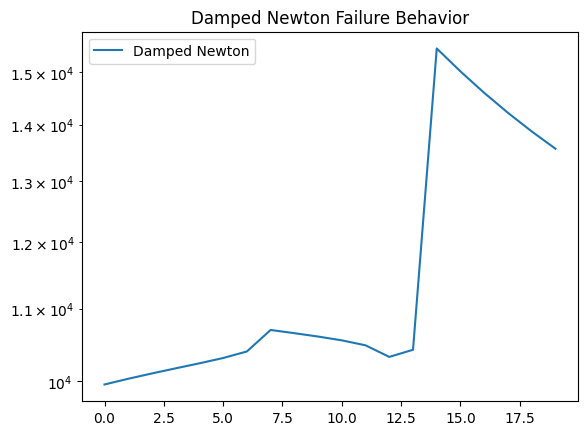

In [10]:
plt.plot(hist_dn, label="Damped Newton")
plt.yscale("log")
plt.legend()
plt.title("Damped Newton Failure Behavior")
plt.show()

In [11]:
def jacobian(a):
    return (x_data * np.exp(a * x_data))[:, None]

In [12]:
def gauss_newton(a0, iters=20):
    a = a0
    history = []
    
    for i in range(iters):
        r = residual(a)
        J = jacobian(a)
        
        JTJ = J.T @ J
        JTr = J.T @ r
        
        try:
            step = -np.linalg.inv(JTJ) @ JTr
        except:
            print("Singular JTJ")
            break
        
        a = a + step.item()
        
        history.append(f(a))
        
        print(f"Iter {i}: a={a:.4f}, f={f(a):.4f}")
    
    return a, history

In [13]:
a_gn, hist_gn = gauss_newton(a0=0.1)

Iter 0: a=8.9570, f=4725260428314050.0000
Iter 1: a=8.4511, f=641247984110242.5000
Iter 2: a=7.9446, f=87056725336415.5625
Iter 3: a=7.4372, f=11824684473408.6055
Iter 4: a=6.9290, f=1607049744344.4697
Iter 5: a=6.4197, f=218557975181.4838
Iter 6: a=5.9093, f=29746466211.3126
Iter 7: a=5.3976, f=4051438190.4040
Iter 8: a=4.8845, f=551893278.8025
Iter 9: a=4.3706, f=75043412.5544
Iter 10: a=3.8575, f=10123292.6833
Iter 11: a=3.3508, f=1331132.3749
Iter 12: a=2.8655, f=162433.8343
Iter 13: a=2.4389, f=16067.8123
Iter 14: a=2.1391, f=886.9746
Iter 15: a=2.0160, f=10.5970
Iter 16: a=1.9995, f=0.6279
Iter 17: a=1.9993, f=0.6256
Iter 18: a=1.9993, f=0.6256
Iter 19: a=1.9993, f=0.6256


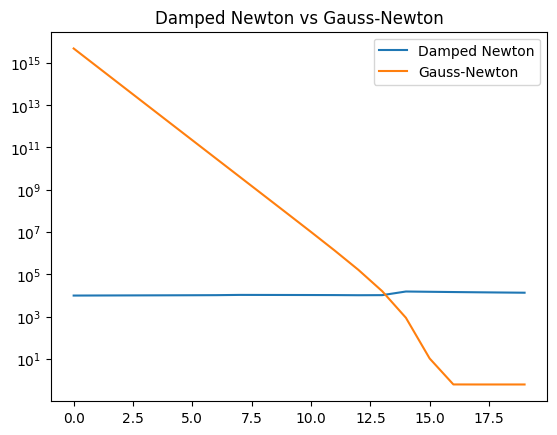

In [14]:
plt.plot(hist_dn, label="Damped Newton")
plt.plot(hist_gn, label="Gauss-Newton")
plt.yscale("log")
plt.legend()
plt.title("Damped Newton vs Gauss-Newton")
plt.show()

In [16]:
a = 0.2

print("Hessian:", hessian(a))
print("JTJ:", jacobian(a).T @ jacobian(a))

Hessian: [[-2357.99741015]]
JTJ: [[83.80505447]]
